In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectFromModel

In [2]:
# Load dataset
file_path = "KDDTrain.csv"
df = pd.read_csv(file_path)
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,intrusion_type
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [3]:
print('Number of data points: ',df.shape[0])
print('Number of features: ', df.shape[1])

Number of data points:  25192
Number of features:  42


In [4]:
output_labels = df['intrusion_type'].unique()
print(f"There are {len(output_labels)} output labels and are: {output_labels}")

There are 22 output labels and are: ['normal' 'neptune' 'warezclient' 'ipsweep' 'portsweep' 'teardrop' 'nmap'
 'satan' 'smurf' 'pod' 'back' 'guess_passwd' 'ftp_write' 'multihop'
 'rootkit' 'buffer_overflow' 'imap' 'warezmaster' 'phf' 'land'
 'loadmodule' 'spy']


In [5]:
# There are no null values
# Checking for duplicate rows
print(f"Duplicate rows - {df.duplicated().sum()}")

Duplicate rows - 0


In [6]:
# Distribution of classes in target label
dist = df['intrusion_type'].value_counts()
for name, count in dist.items(): # Changed iteritems() to items()
    print(f"Number of data points in class: '{str(name)}' is", end=' ') # Convert name to string
    print(f"{count} ({np.round(count / sum(dist) * 100, 3)}%)")

Number of data points in class: 'normal' is 13449 (53.386%)
Number of data points in class: 'neptune' is 8282 (32.876%)
Number of data points in class: 'ipsweep' is 710 (2.818%)
Number of data points in class: 'satan' is 691 (2.743%)
Number of data points in class: 'portsweep' is 587 (2.33%)
Number of data points in class: 'smurf' is 529 (2.1%)
Number of data points in class: 'nmap' is 301 (1.195%)
Number of data points in class: 'back' is 196 (0.778%)
Number of data points in class: 'teardrop' is 188 (0.746%)
Number of data points in class: 'warezclient' is 181 (0.718%)
Number of data points in class: 'pod' is 38 (0.151%)
Number of data points in class: 'guess_passwd' is 10 (0.04%)
Number of data points in class: 'warezmaster' is 7 (0.028%)
Number of data points in class: 'buffer_overflow' is 6 (0.024%)
Number of data points in class: 'imap' is 5 (0.02%)
Number of data points in class: 'rootkit' is 4 (0.016%)
Number of data points in class: 'phf' is 2 (0.008%)
Number of data points in

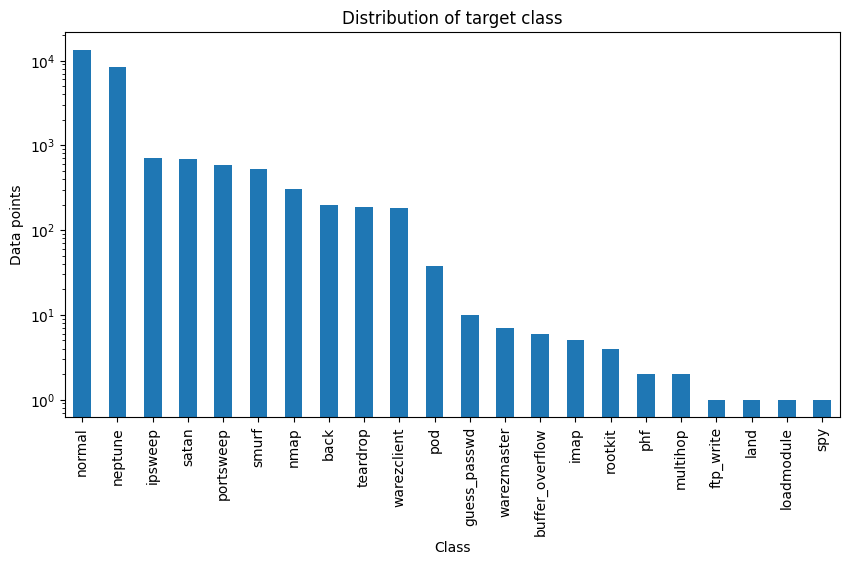

In [7]:
plt.figure(figsize=(10,5))
plt.yscale("log")
dist.plot(kind='bar')
plt.xlabel('Class')
plt.ylabel('Data points')
plt.title('Distribution of target class')
plt.show()

In [8]:
# Encode categorical variables
categorical_cols = ['protocol_type', 'service', 'flag', 'intrusion_type']
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [9]:
# Save the label encoders
joblib.dump(encoders, 'label_encoders.joblib')

['label_encoders.joblib']

In [10]:
# Handle class imbalance by grouping rare classes
threshold = 10
rare_classes = df['intrusion_type'].value_counts()[df['intrusion_type'].value_counts() <= threshold].index
df['intrusion_type'] = df['intrusion_type'].replace(rare_classes, df['intrusion_type'].max() + 1)

In [11]:
# Split features and target variable
X = df.drop(columns=['intrusion_type'])
y = df['intrusion_type']

# Apply SMOTE for class balancing
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [12]:
# Feature Selection using Feature Importance
dt_feature_selector = DecisionTreeClassifier(random_state=42)
dt_feature_selector.fit(X_resampled, y_resampled)
feature_selector = SelectFromModel(dt_feature_selector, prefit=True)
X_selected = feature_selector.transform(X_resampled)
X_train, X_test, y_train, y_test = train_test_split(X_selected, y_resampled, test_size=0.2, random_state=42)

C:\Users\sss\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


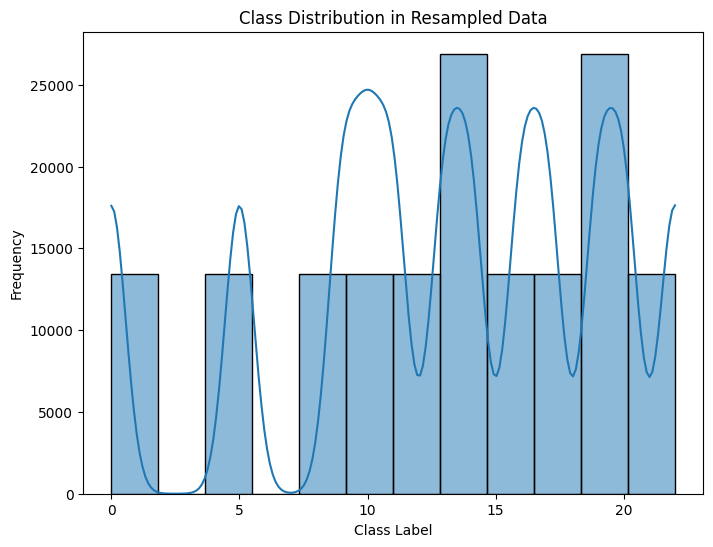

In [13]:
# Histogram for Class Distribution
plt.figure(figsize=(8, 6))
sns.histplot(y_resampled, bins=len(np.unique(y_resampled)), kde=True)
plt.xlabel("Class Label")
plt.ylabel("Frequency")
plt.title("Class Distribution in Resampled Data")
plt.show()

In [14]:
# Hyperparameter tuning and Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {
    'max_depth': [5, 7, 9],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [2, 4, 6]
}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=kf, scoring='accuracy')
grid_search.fit(X_train, y_train)
print(f"Best Parameters: {grid_search.best_params_}")
dt_model = grid_search.best_estimator_

Best Parameters: {'max_depth': 9, 'min_samples_leaf': 6, 'min_samples_split': 5}


In [15]:
# Predict on test data
y_pred = dt_model.predict(X_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

Accuracy: 0.9355
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2710
           5       1.00      0.92      0.96      2693
           9       1.00      0.98      0.99      2571
          10       0.97      0.83      0.89      2691
          11       0.63      0.92      0.75      2618
          13       1.00      0.96      0.98      2764
          14       0.98      0.93      0.96      2655
          16       0.92      0.95      0.94      2707
          17       1.00      0.97      0.98      2737
          19       1.00      1.00      1.00      2703
          20       0.90      1.00      0.95      2783
          22       0.98      0.76      0.86      2646

    accuracy                           0.94     32278
   macro avg       0.95      0.94      0.94     32278
weighted avg       0.95      0.94      0.94     32278



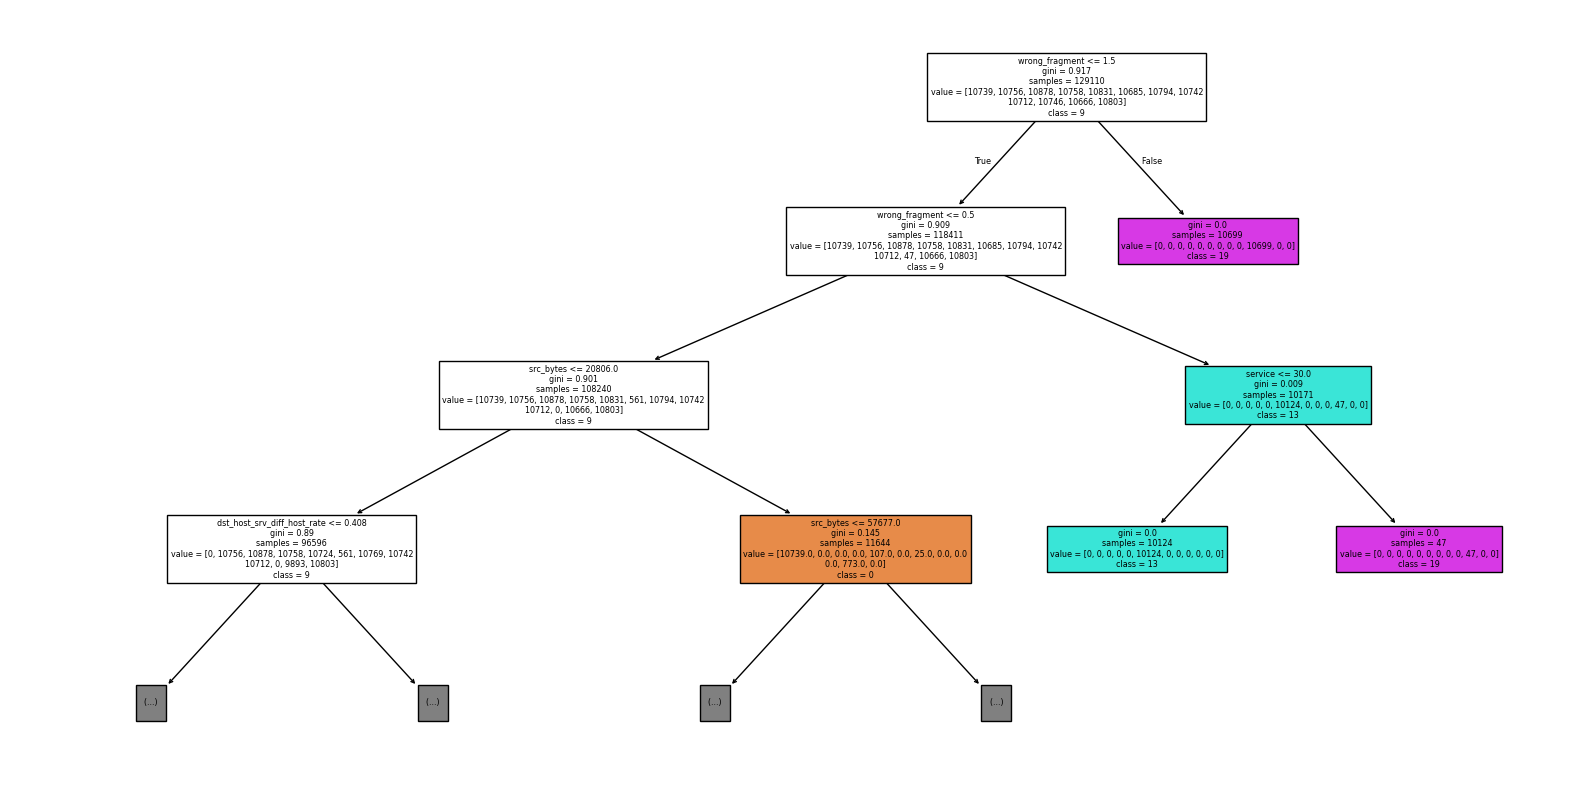

In [16]:
# Plot Decision Tree (limited depth for visualization)
plt.figure(figsize=(20, 10))
selected_feature_names = X_resampled.columns[feature_selector.get_support()]
plot_tree(dt_model, filled=True, feature_names=selected_feature_names, class_names=[str(c) for c in np.unique(y)], max_depth=3)
plt.show()

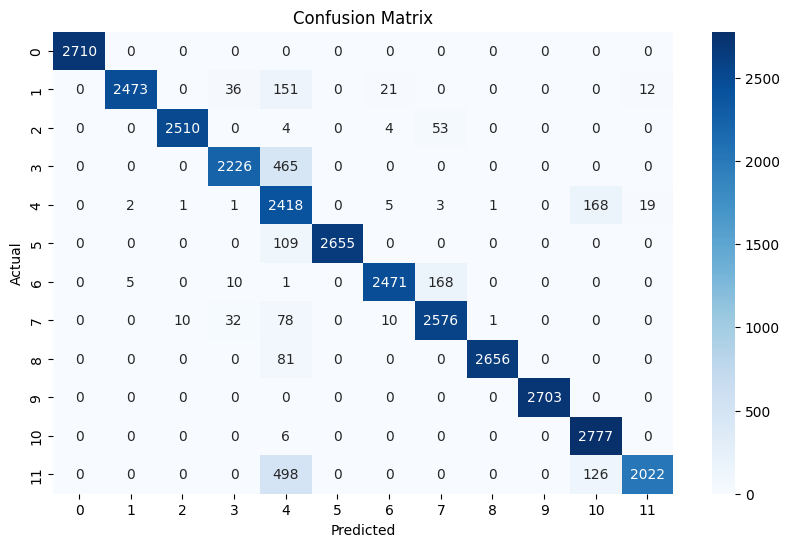

In [17]:
# Plot Confusion Matrix
plt.figure(figsize=(10, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

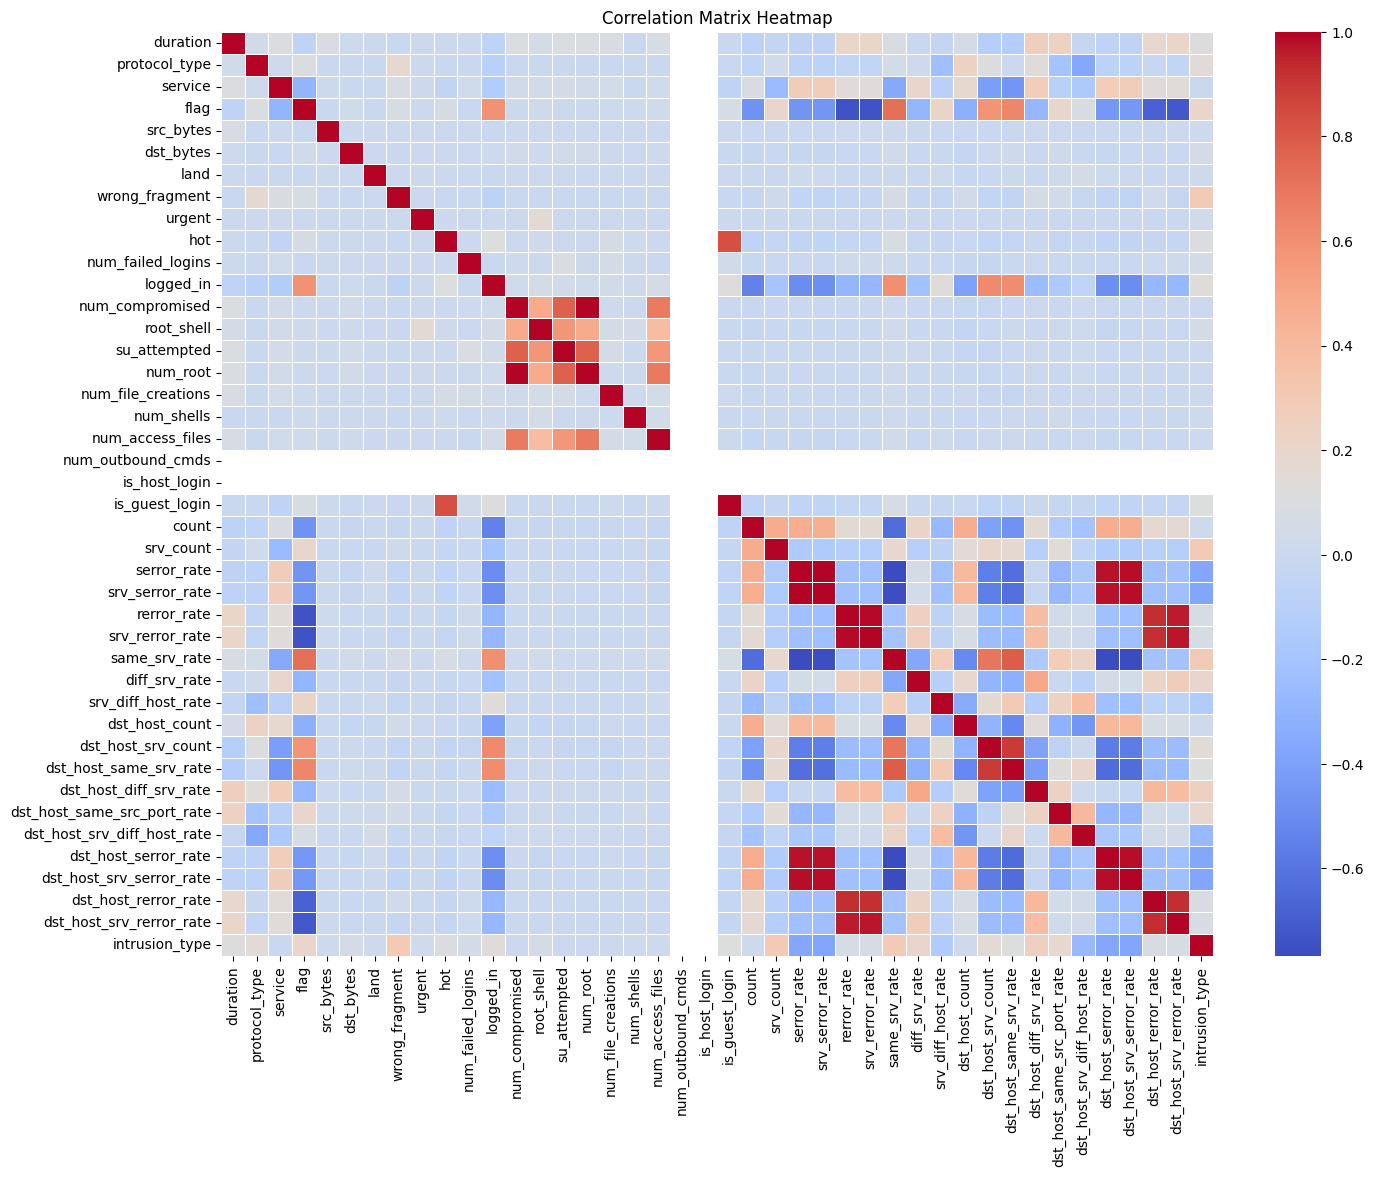

In [18]:
correlation_matrix = df.corr()
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

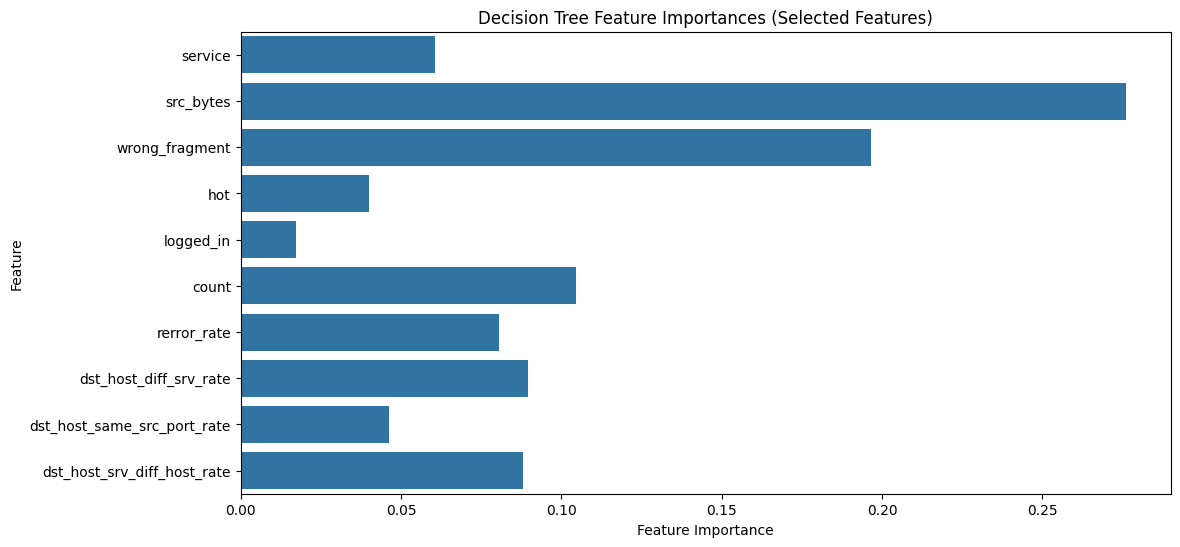

In [19]:
# Feature Importance Visualization
feature_importances = dt_model.feature_importances_
feature_names = X_resampled.columns[feature_selector.get_support()]
plt.figure(figsize=(12, 6))
sns.barplot(x=feature_importances, y=feature_names)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Decision Tree Feature Importances (Selected Features)')
plt.show()

In [20]:
# Cross-Validation Scores
cv_scores = cross_val_score(dt_model, X_train, y_train, cv=kf, scoring='accuracy')
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f}")

Cross-Validation Scores: [0.93052436 0.93416467 0.9326156  0.93691426 0.9343583 ]
Mean CV Accuracy: 0.9337


In [21]:
# Save the model and feature selector
joblib.dump(dt_model, 'ids_model.joblib')
joblib.dump(feature_selector, 'feature_selector.joblib')

['feature_selector.joblib']

In [2]:
#prediction system 
import tkinter as tk
from tkinter import ttk, messagebox, scrolledtext
import pandas as pd
import numpy as np
import joblib
import json

class IntrusionDetectionSystem:
    def __init__(self, root):
        self.root = root
        self.root.title("Intrusion Detection Prediction System")
        self.root.geometry("900x700")
        
        # Load the model and feature selector
        self.model = joblib.load('ids_model.joblib')
        self.feature_selector = joblib.load('feature_selector.joblib')
        self.encoders = joblib.load('label_encoders.joblib')
        
        # Get feature names that were selected
        self.original_features = pd.read_csv("KDDTrain.csv").drop(columns=['intrusion_type']).columns.tolist()
        self.selected_features = [self.original_features[i] for i in range(len(self.original_features)) 
                                 if self.feature_selector.get_support()[i]]
        
        print(f"Selected features: {self.selected_features}")
        print(f"Total selected features: {len(self.selected_features)}")
        
        # Field descriptions for selected features
        self.feature_descriptions = self.get_feature_descriptions()
        
        # Attack descriptions
        self.attack_descriptions = self.get_attack_descriptions()
        
        # Create UI elements
        self.create_widgets()
    
    def get_feature_descriptions(self):
        """Return descriptions for each feature in the KDD dataset"""
        return {
            'duration': 'Length of connection in seconds',
            'protocol_type': 'Type of protocol (tcp, udp, icmp)',
            'service': 'Network service on destination (http, ftp, etc.)',
            'flag': 'Status flag of the connection',
            'src_bytes': 'Bytes sent from source to destination',
            'dst_bytes': 'Bytes sent from destination to source',
            'land': 'If source/destination IPs/ports are same (1) or not (0)',
            'wrong_fragment': 'Number of wrong fragments',
            'urgent': 'Number of urgent packets',
            'hot': 'Number of "hot" indicators',
            'num_failed_logins': 'Number of failed login attempts',
            'logged_in': 'Successfully logged in (1) or not (0)',
            'num_compromised': 'Number of compromised conditions',
            'root_shell': 'Root shell obtained (1) or not (0)',
            'su_attempted': 'Su root command attempted (1) or not (0)',
            'num_root': 'Number of root accesses',
            'num_file_creations': 'Number of file creation operations',
            'num_shells': 'Number of shell prompts',
            'num_access_files': 'Number of operations on access control files',
            'num_outbound_cmds': 'Number of outbound commands in ftp session',
            'is_host_login': 'If login belongs to "host" list (1) or not (0)',
            'is_guest_login': 'If login is a guest login (1) or not (0)',
            'count': 'Number of connections to same host in past 2 seconds',
            'srv_count': 'Number of connections to same service in past 2 seconds',
            'serror_rate': 'Percentage of connections with SYN errors',
            'srv_serror_rate': 'Percentage of service connections with SYN errors',
            'rerror_rate': 'Percentage of connections with REJ errors',
            'srv_rerror_rate': 'Percentage of service connections with REJ errors',
            'same_srv_rate': 'Percentage of connections to same service',
            'diff_srv_rate': 'Percentage of connections to different services',
            'srv_diff_host_rate': 'Percentage of connections to different hosts',
            'dst_host_count': 'Count of connections to same destination host',
            'dst_host_srv_count': 'Count of connections to same destination host service',
            'dst_host_same_srv_rate': 'Same service rate for destination host',
            'dst_host_diff_srv_rate': 'Different service rate for destination host',
            'dst_host_same_src_port_rate': 'Same source port rate for destination host',
            'dst_host_srv_diff_host_rate': 'Different host rate for destination host service',
            'dst_host_serror_rate': 'SYN error rate for destination host',
            'dst_host_srv_serror_rate': 'SYN error rate for destination host service',
            'dst_host_rerror_rate': 'REJ error rate for destination host',
            'dst_host_srv_rerror_rate': 'REJ error rate for destination host service'
        }
    
    def get_attack_descriptions(self):
        """Return descriptions for each attack type"""
        return {
            "normal": "No malicious activity detected. Regular network traffic.",
            "buffer_overflow": "Attempt to exploit buffer overflow vulnerability in target system.",
            "loadmodule": "Attempt to load unauthorized module into system.",
            "perl": "Attack using Perl programming language to exploit vulnerabilities.",
            "neptune": "SYN flood DoS attack overwhelming target with connection requests.",
            "smurf": "ICMP flood attack using spoofed source IP addresses.",
            "guess_passwd": "Brute force attempt to guess user passwords.",
            "pod": "Ping of Death attack sending malformed or oversized packets.",
            "teardrop": "Attack exploiting fragmented IP packet reassembly vulnerability.",
            "portsweep": "Reconnaissance scanning multiple ports to find vulnerabilities.",
            "ipsweep": "Reconnaissance scanning multiple IP addresses to map network.",
            "land": "Attack sending packets with identical source and destination.",
            "ftp_write": "Unauthorized writing to system files via FTP.",
            "back": "Attack against web servers causing denial of service.",
            "imap": "Attempt to exploit vulnerabilities in IMAP email protocol.",
            "satan": "Network scanning tool for identifying vulnerabilities.",
            "phf": "Attack exploiting vulnerabilities in CGI scripts.",
            "nmap": "Network mapping tool used for reconnaissance.",
            "multihop": "Compromising multiple systems to hide attack origin.",
            "warezmaster": "Hosting illegal content on compromised FTP servers.",
            "warezclient": "Downloading illegal content from compromised servers.",
            "spy": "Unauthorized information gathering or surveillance.",
            "rootkit": "Malicious software designed to gain unauthorized root access."
        }
    
    def create_widgets(self):
        # Create a main frame with scrollbar
        main_frame = ttk.Frame(self.root)
        main_frame.pack(fill=tk.BOTH, expand=True, padx=10, pady=10)
        
        # Create a canvas with scrollbar for the input fields
        canvas = tk.Canvas(main_frame)
        scrollbar = ttk.Scrollbar(main_frame, orient=tk.VERTICAL, command=canvas.yview)
        scrollable_frame = ttk.Frame(canvas)
        
        scrollable_frame.bind(
            "<Configure>",
            lambda e: canvas.configure(scrollregion=canvas.bbox("all"))
        )
        
        canvas.create_window((0, 0), window=scrollable_frame, anchor="nw")
        canvas.configure(yscrollcommand=scrollbar.set)
        
        canvas.pack(side=tk.LEFT, fill=tk.BOTH, expand=True)
        scrollbar.pack(side=tk.RIGHT, fill=tk.Y)
        
        # Title
        ttk.Label(scrollable_frame, text="Intrusion Detection System", font=("Arial", 16, "bold")).grid(
            column=0, row=0, columnspan=3, pady=10, sticky=tk.W)
        
        # Description
        ttk.Label(scrollable_frame, text=f"Enter the {len(self.selected_features)} required network connection parameters:", 
                 font=("Arial", 10)).grid(column=0, row=1, columnspan=3, pady=5, sticky=tk.W)
        
        # Create input fields for each selected feature
        self.input_widgets = {}
        current_row = 2
        
        # Create fields for categorical and numerical features
        categorical_features = ['protocol_type', 'service', 'flag']
        
        for i, feature in enumerate(self.selected_features):
            # Feature name
            ttk.Label(scrollable_frame, text=feature).grid(
                column=0, row=current_row, padx=5, pady=2, sticky=tk.W)
            
            # Feature description
            desc = self.feature_descriptions.get(feature, "")
            ttk.Label(scrollable_frame, text=desc, font=("Arial", 8, "italic")).grid(
                column=2, row=current_row, padx=5, pady=2, sticky=tk.W)
            
            # Input field based on feature type
            if feature in categorical_features:
                # For categorical features, create dropdown menus
                values = list(self.encoders[feature].classes_)
                combo = ttk.Combobox(scrollable_frame, values=values, width=30)
                if values:
                    combo.current(0)
                combo.grid(column=1, row=current_row, padx=5, pady=2, sticky=tk.W)
                self.input_widgets[feature] = combo
            else:
                # For numerical features, create text entries
                entry = ttk.Entry(scrollable_frame, width=30)
                entry.grid(column=1, row=current_row, padx=5, pady=2, sticky=tk.W)
                entry.insert(0, "0")
                self.input_widgets[feature] = entry
                
            current_row += 1
        
        # Add predict button
        predict_button = ttk.Button(scrollable_frame, text="Predict", command=self.predict)
        predict_button.grid(column=0, row=current_row, columnspan=3, pady=20)
        current_row += 1
        
        # Add result display area
        ttk.Label(scrollable_frame, text="Prediction Result:", font=("Arial", 10, "bold")).grid(
            column=0, row=current_row, columnspan=3, pady=5, sticky=tk.W)
        current_row += 1
        
        self.result_display = scrolledtext.ScrolledText(scrollable_frame, width=80, height=10)
        self.result_display.grid(column=0, row=current_row, columnspan=3, pady=5)
        
    def get_input_values(self):
        """Get values from input fields and prepare for prediction"""
        # First create a dataframe with all original features (initialized to 0)
        input_data = {feature: 0 for feature in self.original_features}
        
        # Then fill in the values for the selected features
        for feature in self.selected_features:
            widget = self.input_widgets[feature]
            
            if feature in ['protocol_type', 'service', 'flag']:
                # For categorical features, encode the value
                value = widget.get()
                encoded_value = self.encoders[feature].transform([value])[0]
                input_data[feature] = encoded_value
            else:
                # For numerical features, convert to float
                try:
                    input_data[feature] = float(widget.get())
                except ValueError:
                    messagebox.showerror("Input Error", f"Invalid value for {feature}. Please enter a number.")
                    return None
        
        return pd.DataFrame([input_data])
    
    def predict(self):
        """Make prediction based on input values"""
        # Get input values
        input_df = self.get_input_values()
        if input_df is None:
            return
            
        try:
            # Apply feature selection
            input_selected = self.feature_selector.transform(input_df)
            
            # Make prediction
            prediction = self.model.predict(input_selected)[0]
            
            # Get attack type names
            attack_type = self.get_attack_types(prediction)
            
            # Display results
            self.display_results(attack_type)
            
        except Exception as e:
            messagebox.showerror("Prediction Error", f"An error occurred: {str(e)}")
            import traceback
            traceback.print_exc()
    
    def get_attack_types(self, prediction):
        """Map prediction code to attack type description"""
        # Try to get the reverse mapping from encoders
        if 'intrusion_type' in self.encoders:
            try:
                # Use the encoder to get the original label
                attack_name = self.encoders['intrusion_type'].inverse_transform([prediction])[0]
                return attack_name
            except:
                pass
        
        # Fallback to generic attack types
        attack_mapping = {
            0: "normal",
            1: "buffer_overflow",
            2: "loadmodule",
            3: "perl",
            4: "neptune",
            5: "smurf",
            6: "guess_passwd",
            7: "pod",
            8: "teardrop",
            9: "portsweep",
            10: "ipsweep",
            11: "land",
            12: "ftp_write",
            13: "back",
            14: "imap",
            15: "satan",
            16: "phf",
            17: "nmap",
            18: "multihop",
            19: "warezmaster",
            20: "warezclient",
            21: "spy",
            22: "rootkit",
            23: "rare/unknown attack"
        }
        
        return attack_mapping.get(prediction, f"Unknown attack type (class {prediction})")
    
    def display_results(self, attack_type):
        """Display simplified prediction results in the result area"""
        self.result_display.delete(1.0, tk.END)
        
        # Get attack description
        description = self.attack_descriptions.get(attack_type, "Unknown attack type with no detailed description.")
        
        # Format the simplified results
        results = f"Attack Type: {attack_type}\n\n"
        results += f"Description: {description}"
        
        self.result_display.insert(tk.END, results)
    def display_results(self, attack_type):
        self.result_display.delete(1.0, tk.END)

        description = self.attack_descriptions.get(attack_type, "Unknown attack type with no detailed description.")
        color = "green" if attack_type.lower() == "normal" else "red"

        self.result_display.tag_configure("attack", font=("Arial", 14, "bold"), foreground=color)
        self.result_display.tag_configure("description", font=("Arial", 10))

        self.result_display.insert(tk.END, f"Attack Type: {attack_type}\n", "attack")
        self.result_display.insert(tk.END, f"\n\nDescription: {description}", "description")
if __name__ == "__main__":
    try:
        root = tk.Tk()
        app = IntrusionDetectionSystem(root)
        root.mainloop()
    except Exception as e:
        print(f"Error: {str(e)}")
        import traceback
        traceback.print_exc()


Selected features: ['service', 'src_bytes', 'wrong_fragment', 'hot', 'logged_in', 'count', 'rerror_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate']
Total selected features: 10


C:\Users\sss\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\sss\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
